## Linear regression model with normal equation

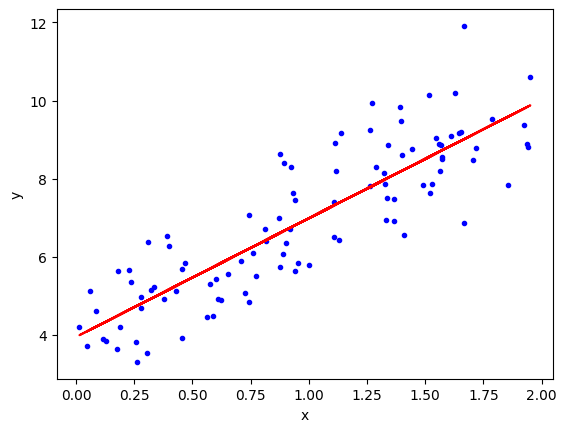

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# normal equation: used to find optimal theta that minimises cost function (MSE)
def normal_eqn(x, y):
    return np.linalg.inv(x.T @ x) @ x.T @ y

# train model
def fit_linear_reg(x, y):
    x = np.asarray(x)
    y = np.asarray(y).reshape(-1, 1)
    x = np.c_[np.ones((x.shape[0], 1)), x]
    theta = normal_eqn(x, y) # apply normal equation
    return theta

# use model for prediction
def predict_linear_reg(x, theta):
    x = np.asarray(x)
    x = np.c_[np.ones((x.shape[0], 1)), x]
    return x @ theta

# generate sample dataset
rng = np.random.default_rng(seed=42)
x = 2 * rng.random((100, 1))
y = 4 + 3 * x + rng.standard_normal((100, 1))
theta = fit_linear_reg(x, y)
y_pred = predict_linear_reg(x, theta)

# plot results
plt.plot(x, y, 'b.')
plt.plot(x, y_pred, 'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Batch Gradient Descent (Training model)

In [14]:
def batch_GD(x, y, iterations=1000, learning_rate=0.1):
    m = len(x)
    x = np.c_[np.ones((m, 1)), x]
    theta = rng.random((x.shape[1], 1))
    for i in range(iterations):
        gradients = 2/m * x.T @ (x @ theta - y) # get gradient vector
        theta = theta - learning_rate * gradients # improve parameters
    
    return theta
batch_GD(x, y)

array([[3.94869973],
       [3.03831479]])

## Stochastic Gradient Descent (Training model)

In [13]:
def stoch_GD(x, y, iterations=1000, t0=5, t1=50):
    def learning_schedule(t):
        return t0 / (t + t1)

    m = len(x)
    x = np.c_[np.ones((m, 1)), x]
    theta = rng.random((x.shape[1], 1))

    for i in range(iterations):
        for j in range(m):
            random_idx = rng.integers(m)
            xi = x[random_idx:random_idx+1]
            yi = y[random_idx:random_idx+1]
            gradients = 2 * xi.T @ (xi @ theta - yi)
            learning_rate = learning_schedule(i * m + j)
            theta = theta - learning_rate * gradients
    
    return theta
stoch_GD(x, y)

array([[3.94902117],
       [3.03159651]])

## Learning curve

#### Used to gauage whether model is over or underfitted and estimates training size threshold beyond which error does not reduce

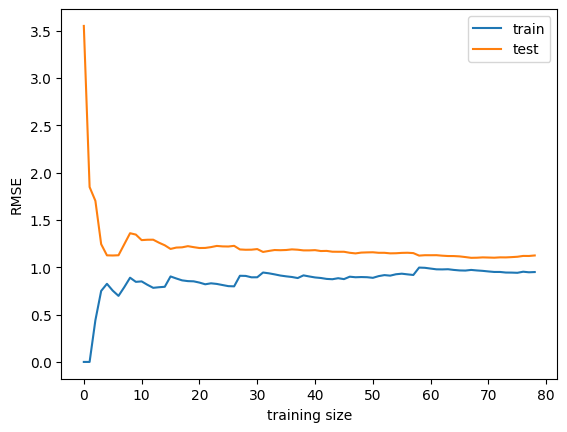

In [6]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def learning_curve(model, x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
    train_errors, test_errors = [], []
    for m in range(1, len(x_train)): # get error for each sample size
        model.fit(x_train[:m], y_train[:m])
        y_train_predict = model.predict(x_train[:m])
        y_test_predict = model.predict(x_test)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        test_errors.append(mean_squared_error(y_test, y_test_predict))

    plt.plot(np.sqrt(train_errors), label='train')
    plt.plot(np.sqrt(test_errors), label='test')
    plt.xlabel('training size')
    plt.ylabel('RMSE')
    plt.legend()
    plt.show()

from sklearn.linear_model import LinearRegression
lg = LinearRegression()
learning_curve(lg, x, y)

#### ^^ model is underfitted as test error plateaus when training size grows beyond 30-ish instances